In [1]:
# ============================================
# House Prices ML Prediction
# Author: xipecast
# Date: 2026
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Settings
pd.set_option('display.max_columns', 50)
plt.style.use('seaborn-v0_8')

print("Libraries loaded!")

Libraries loaded!


In [2]:
# Load Data
df = pd.read_csv('/mnt/SSD/ssd_Documents/PROJECTS/analyst-portfolio/house-prices/data/train.csv')

print(f"Shape: {df.shape}")
print(f"\nFirst 5 rows:")
df.head()

Shape: (1460, 81)

First 5 rows:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,...,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,...,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,...,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,...,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,...,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,...,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
# Load Data
df = pd.read_csv('/mnt/SSD/ssd_Documents/PROJECTS/analyst-portfolio/house-prices/data/train.csv')

print(f"Shape: {df.shape}")
print(f"\nFirst 5 rows:")
df.head()

Shape: (1460, 81)

First 5 rows:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,...,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,...,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,...,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,...,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,...,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,...,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [5]:
df.isnull().sum().sort_values(ascending=False).head(20)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
GarageYrBlt       81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
Condition2         0
dtype: int64

In [6]:
# Drop high missing columns
df_clean = df.drop(columns=['PoolQC', 'MiscFeature', 'Alley', 'Fence'])

# Fill missing values
df_clean['LotFrontage'] = df_clean['LotFrontage'].fillna(df_clean['LotFrontage'].median())
df_clean['FireplaceQu'] = df_clean['FireplaceQu'].fillna('None')
df_clean['GarageType'] = df_clean['GarageType'].fillna('None')
df_clean['GarageFinish'] = df_clean['GarageFinish'].fillna('None')
df_clean['GarageQual'] = df_clean['GarageQual'].fillna('None')
df_clean['GarageCond'] = df_clean['GarageCond'].fillna('None')
df_clean['GarageYrBlt'] = df_clean['GarageYrBlt'].fillna(0)
df_clean['BsmtQual'] = df_clean['BsmtQual'].fillna('None')
df_clean['BsmtCond'] = df_clean['BsmtCond'].fillna('None')
df_clean['BsmtExposure'] = df_clean['BsmtExposure'].fillna('None')
df_clean['BsmtFinType1'] = df_clean['BsmtFinType1'].fillna('None')
df_clean['BsmtFinType2'] = df_clean['BsmtFinType2'].fillna('None')
df_clean['MasVnrType'] = df_clean['MasVnrType'].fillna('None')
df_clean['MasVnrArea'] = df_clean['MasVnrArea'].fillna(0)
df_clean['Electrical'] = df_clean['Electrical'].fillna('SBrkr')

print(f"Clean shape: {df_clean.shape}")
print(f"Missing values remaining: {df_clean.isnull().sum().sum()}")

Clean shape: (1460, 77)
Missing values remaining: 0


<Axes: xlabel='SalePrice', ylabel='Count'>

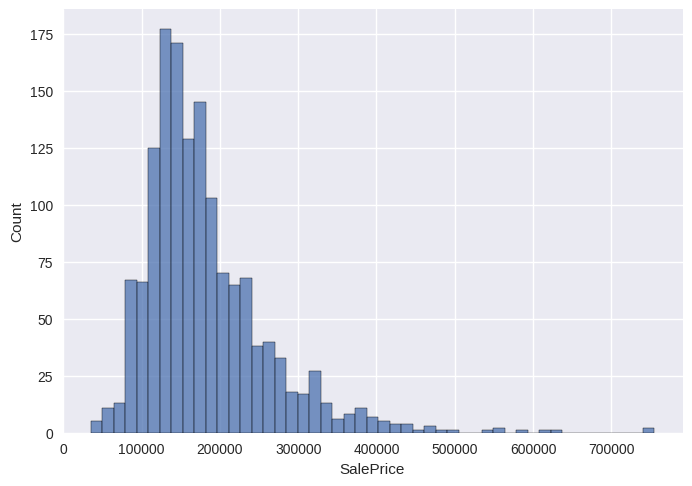

In [7]:
# Visualize SalePrice distribution
sns.histplot(df_clean['SalePrice'])

In [8]:
# Encode categorical variables

In [9]:
# Prepare X and y
X = df_clean.drop('SalePrice', axis=1)
y = df_clean['SalePrice']


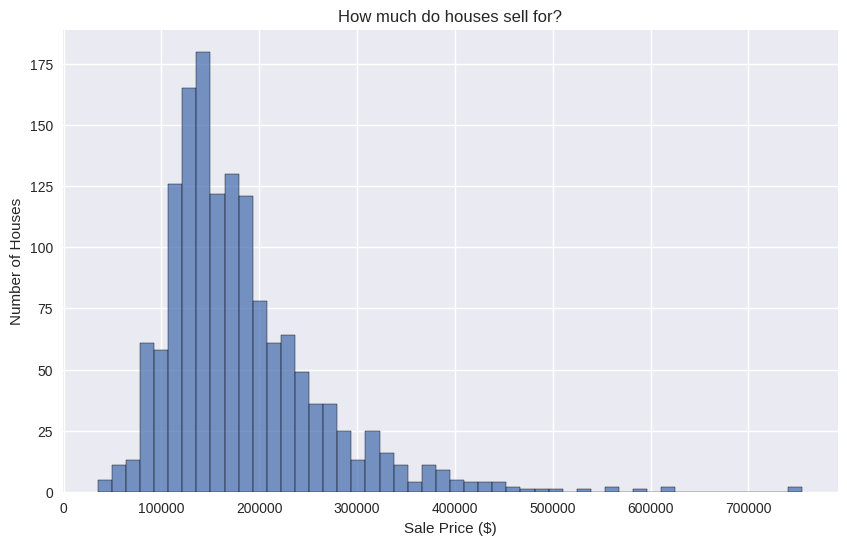

Cheapest house: $34,900
Most expensive: $755,000
Average price: $180,921


In [10]:
# Let's look at house prices!
plt.figure(figsize=(10,6))
sns.histplot(df_clean['SalePrice'], bins=50)
plt.title('How much do houses sell for?')
plt.xlabel('Sale Price ($)')
plt.ylabel('Number of Houses')
plt.show()

print(f"Cheapest house: ${df_clean['SalePrice'].min():,}")
print(f"Most expensive: ${df_clean['SalePrice'].max():,}")
print(f"Average price: ${df_clean['SalePrice'].mean():,.0f}")

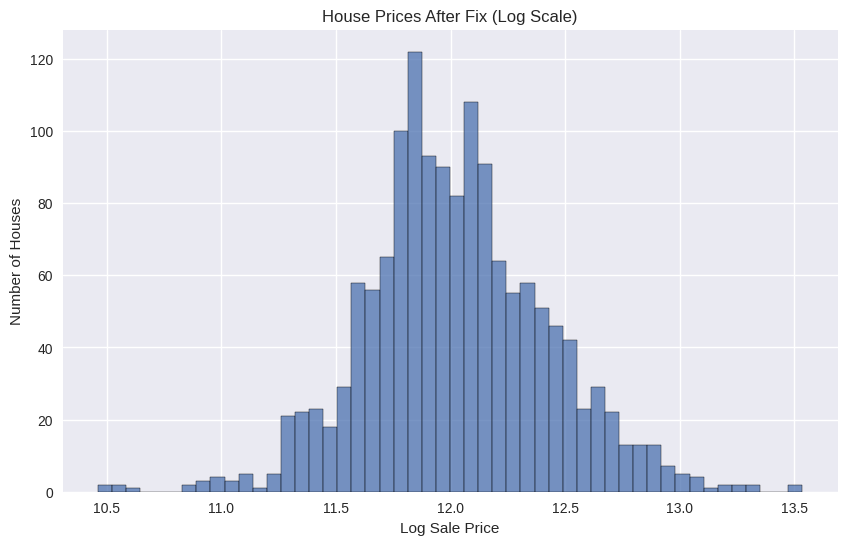

In [11]:
# Fix the skew!
df_clean['SalePrice_Log'] = np.log1p(df_clean['SalePrice'])

plt.figure(figsize=(10,6))
sns.histplot(df_clean['SalePrice_Log'], bins=50)
plt.title('House Prices After Fix (Log Scale)')
plt.xlabel('Log Sale Price')
plt.ylabel('Number of Houses')
plt.show()


In [13]:
# What affects house prices the most?
plt.figure(figsize=(10,6))
correlation = df_clean.select_dtypes(include=[np.number]).corr()
top_features = correlation['SalePrice'].sort_values(ascending=False).head(11)
print(top_features)

SalePrice        1.000000
SalePrice_Log    0.948374
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
Name: SalePrice, dtype: float64


<Figure size 1000x600 with 0 Axes>

In [14]:
# What affects house prices the most?
# (skip SalePrice itself!)
plt.figure(figsize=(10,6))
correlation = df_clean.select_dtypes(include=[np.number]).corr()
top_features = correlation['SalePrice'].sort_values(ascending=False)[1:11]
print(top_features)

SalePrice_Log    0.948374
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
Name: SalePrice, dtype: float64


<Figure size 1000x600 with 0 Axes>

In [16]:
# Skip SalePrice AND SalePrice_Log
correlation = df_clean.select_dtypes(include=[np.number]).corr()
top_features = correlation['SalePrice'].drop(['SalePrice', 'SalePrice_Log']).sort_values(ascending=False).head(10)
print(top_features)

OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
Name: SalePrice, dtype: float64


In [17]:
# Pick our top features
top_features = ['OverallQual', 'GrLivArea', 'GarageCars', 
                'GarageArea', 'TotalBsmtSF', '1stFlrSF',
                'FullBath', 'TotRmsAbvGrd', 'YearBuilt', 
                'YearRemodAdd']

# Separate features from price
X = df_clean[top_features]
y = df_clean['SalePrice_Log']

# Split into learning pile (80%) and testing pile (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f"Learning pile: {X_train.shape[0]} houses")
print(f"Testing pile: {X_test.shape[0]} houses")

Learning pile: 1168 houses
Testing pile: 292 houses


In [18]:
# Train the robot!
model = LinearRegression()
model.fit(X_train, y_train)

# Test the robot!
y_pred = model.predict(X_test)

# How did it do?
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R² Score: 0.8440
RMSE: 0.1706


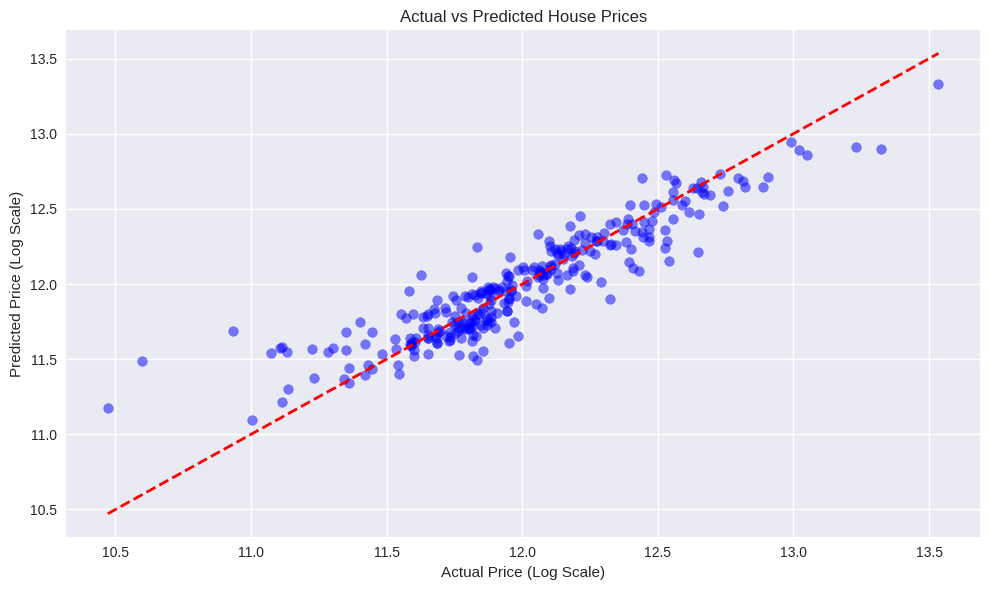

In [19]:
# Visualize predictions vs actual prices
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 
         'r--', linewidth=2)

plt.xlabel('Actual Price (Log Scale)')
plt.ylabel('Predicted Price (Log Scale)')
plt.title('Actual vs Predicted House Prices')
plt.tight_layout()
plt.show()

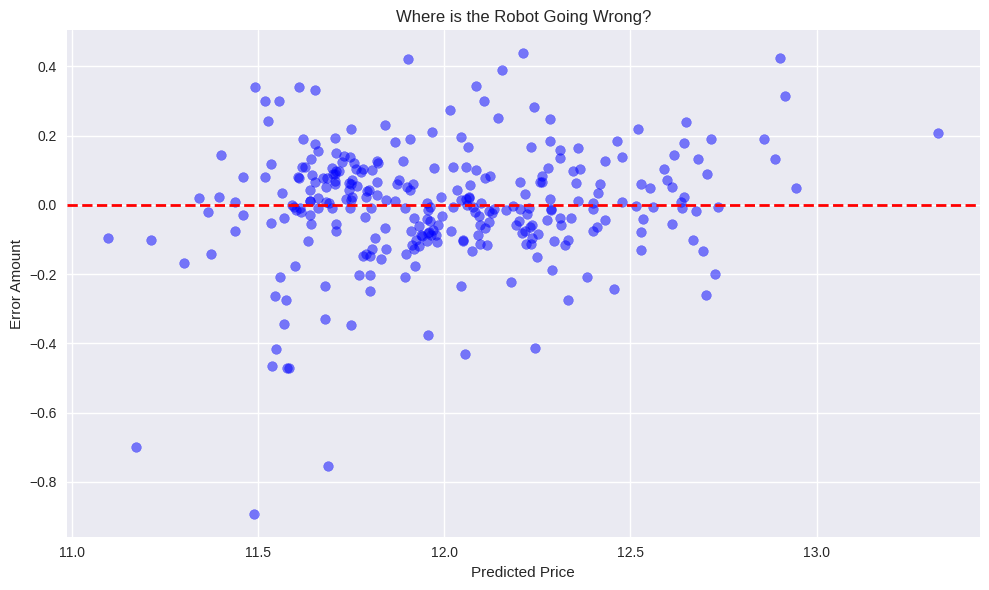

In [21]:
# Where is the robot going wrong?
residuals = y_test - y_pred

plt.figure(figsize=(10,6))
plt.scatter(y_pred, residuals, alpha=0.5, color='blue')
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
plt.xlabel('Predicted Price')
plt.ylabel('Error Amount')
plt.title('Where is the Robot Going Wrong?')
plt.tight_layout()
plt.show()

In [22]:
from sklearn.ensemble import RandomForestRegressor

In [23]:
# Upgrade to Random Forest!
rf_model = RandomForestRegressor(
    n_estimators=100,  # 100 decision trees
    random_state=42
)

# Train it!
rf_model.fit(X_train, y_train)

# Test it!
rf_pred = rf_model.predict(X_test)

# How did it do?
rf_r2 = r2_score(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

print("Random Forest Results:")
print(f"R² Score: {rf_r2:.4f}")
print(f"RMSE: {rf_rmse:.4f}")
print("---")
print("Linear Regression Results:")
print(f"R² Score: 0.8440")
print(f"RMSE: 0.1706")

Random Forest Results:
R² Score: 0.8517
RMSE: 0.1664
---
Linear Regression Results:
R² Score: 0.8440
RMSE: 0.1706


In [24]:
# Convert words to numbers!
df_encoded = pd.get_dummies(df_clean.drop(columns=['SalePrice_Log']), 
                            drop_first=True)

# Separate features from price
X_all = df_encoded.drop(columns=['SalePrice'])
y_all = df_clean['SalePrice_Log']

# Split again
X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42)

print(f"Total features now: {X_all.shape[1]}")
print(f"Learning pile: {X_train_all.shape[0]} houses")
print(f"Testing pile: {X_test_all.shape[0]} houses")

Total features now: 247
Learning pile: 1168 houses
Testing pile: 292 houses


In [25]:
# Train Random Forest with ALL features!
rf_model_all = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train it!
rf_model_all.fit(X_train_all, y_train_all)

# Test it!
rf_pred_all = rf_model_all.predict(X_test_all)

# How did it do?
rf_r2_all = r2_score(y_test_all, rf_pred_all)
rf_rmse_all = np.sqrt(mean_squared_error(y_test_all, rf_pred_all))

print("Random Forest (ALL Features):")
print(f"R² Score: {rf_r2_all:.4f}")
print(f"RMSE: {rf_rmse_all:.4f}")
print("---")
print("Random Forest (10 Features):")
print(f"R² Score: 0.8517")
print(f"RMSE: 0.1664")

Random Forest (ALL Features):
R² Score: 0.8812
RMSE: 0.1489
---
Random Forest (10 Features):
R² Score: 0.8517
RMSE: 0.1664


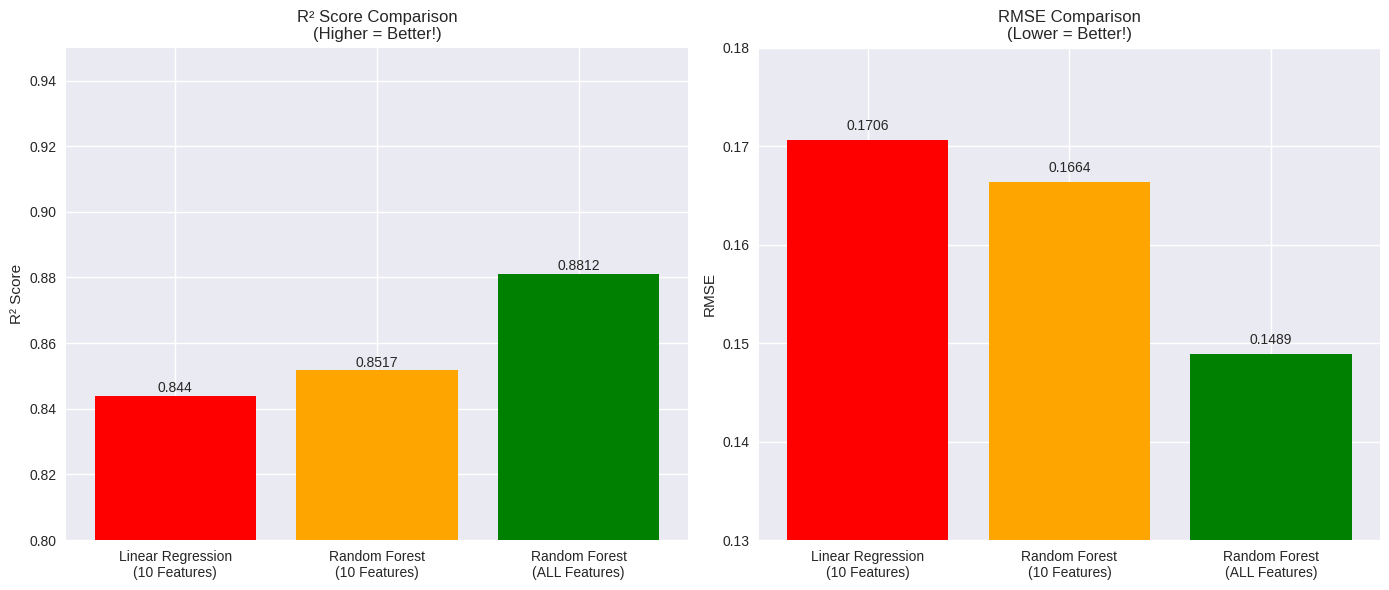

In [26]:
# Model Comparison Chart!
models = ['Linear Regression\n(10 Features)', 
          'Random Forest\n(10 Features)', 
          'Random Forest\n(ALL Features)']

r2_scores = [0.8440, 0.8517, 0.8812]
rmse_scores = [0.1706, 0.1664, 0.1489]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,6))

# R² Chart
ax1.bar(models, r2_scores, color=['red', 'orange', 'green'])
ax1.set_title('R² Score Comparison\n(Higher = Better!)')
ax1.set_ylim(0.8, 0.95)
ax1.set_ylabel('R² Score')
for i, v in enumerate(r2_scores):
    ax1.text(i, v + 0.001, str(v), ha='center')

# RMSE Chart
ax2.bar(models, rmse_scores, color=['red', 'orange', 'green'])
ax2.set_title('RMSE Comparison\n(Lower = Better!)')
ax2.set_ylim(0.13, 0.18)
ax2.set_ylabel('RMSE')
for i, v in enumerate(rmse_scores):
    ax2.text(i, v + 0.001, str(v), ha='center')

plt.tight_layout()
plt.show()

/tmp/ipykernel_39395/353690453.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis')


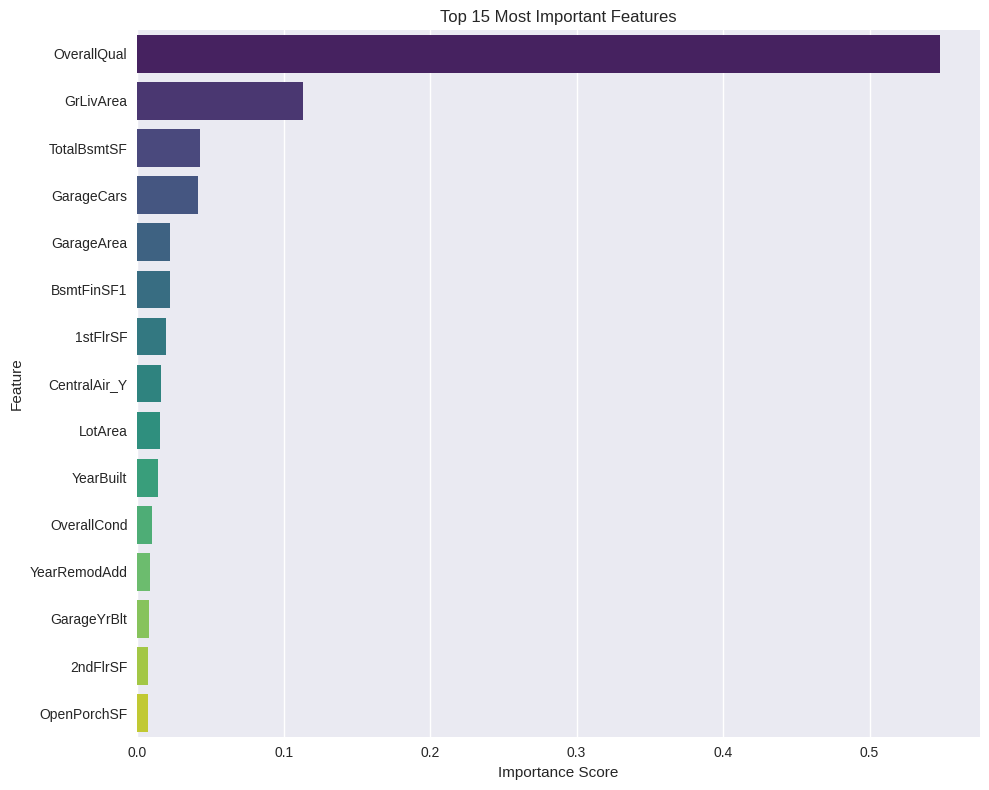

     Feature  Importance
 OverallQual    0.547984
   GrLivArea    0.113368
 TotalBsmtSF    0.043148
  GarageCars    0.041371
  GarageArea    0.022688
  BsmtFinSF1    0.022342
    1stFlrSF    0.019762
CentralAir_Y    0.016415
     LotArea    0.015286
   YearBuilt    0.014114
 OverallCond    0.010062
YearRemodAdd    0.008513
 GarageYrBlt    0.007976
    2ndFlrSF    0.007511
 OpenPorchSF    0.007105


In [27]:
# What does the robot think is most important?
feature_importance = pd.DataFrame({
    'Feature': X_train_all.columns,
    'Importance': rf_model_all.feature_importances_
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    'Importance', ascending=False).head(15)

plt.figure(figsize=(10,8))
sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis')
plt.title('Top 15 Most Important Features')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print(feature_importance.to_string(index=False))

In [29]:
import sys
!{sys.executable} -m pip install xgboost

  Using cached xgboost-3.2.0-py3-none-manylinux_2_28_x86_64.whl.metadata (2.1 kB)
  Using cached nvidia_nccl_cu12-2.29.7-py3-none-manylinux_2_18_x86_64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-manylinux_2_28_x86_64.whl (131.7 MB)
Using cached nvidia_nccl_cu12-2.29.7-py3-none-manylinux_2_18_x86_64.whl (293.6 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [xgboost]━━━ 1/2 [xgboost]


In [30]:
from xgboost import XGBRegressor

# Train XGBoost!
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

# Train it!
xgb_model.fit(X_train_all, y_train_all)

# Test it!
xgb_pred = xgb_model.predict(X_test_all)

# How did it do?
xgb_r2 = r2_score(y_test_all, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test_all, xgb_pred))

print("XGBoost Results:")
print(f"R² Score: {xgb_r2:.4f}")
print(f"RMSE: {xgb_rmse:.4f}")
print("---")
print("Random Forest (ALL Features):")
print(f"R² Score: 0.8812")
print(f"RMSE: 0.1489")

XGBoost Results:
R² Score: 0.8853
RMSE: 0.1463
---
Random Forest (ALL Features):
R² Score: 0.8812
RMSE: 0.1489


In [31]:
from sklearn.model_selection import GridSearchCV

# Different settings to try
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 6],
    'min_child_weight': [1, 3, 5]
}

# Try all combinations!
xgb_tuned = GridSearchCV(
    XGBRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2',
    verbose=1
)

xgb_tuned.fit(X_train_all, y_train_all)

print(f"Best Settings: {xgb_tuned.best_params_}")
print(f"Best R² Score: {xgb_tuned.best_score_:.4f}")

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best Settings: {'learning_rate': 0.1, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 300}
Best R² Score: 0.8858


In [32]:
# Train with best settings!
xgb_best = XGBRegressor(
    learning_rate=0.1,
    max_depth=3,
    min_child_weight=1,
    n_estimators=300,
    random_state=42
)

xgb_best.fit(X_train_all, y_train_all)
xgb_best_pred = xgb_best.predict(X_test_all)

xgb_best_r2 = r2_score(y_test_all, xgb_best_pred)
xgb_best_rmse = np.sqrt(mean_squared_error(y_test_all, xgb_best_pred))

print("Tuned XGBoost Results:")
print(f"R² Score: {xgb_best_r2:.4f}")
print(f"RMSE: {xgb_best_rmse:.4f}")
print("---")
print("Original XGBoost:")
print(f"R² Score: 0.8853")
print(f"RMSE: 0.1463")

Tuned XGBoost Results:
R² Score: 0.9096
RMSE: 0.1299
---
Original XGBoost:
R² Score: 0.8853
RMSE: 0.1463


In [33]:
import joblib

# Save our best model!
joblib.dump(xgb_best, 'outputs/house_prices_model.pkl')

print("Model saved to outputs/house_prices_model.pkl ✅")

# Test that it saved correctly!
loaded_model = joblib.load('outputs/house_prices_model.pkl')
test_pred = loaded_model.predict(X_test_all)
test_r2 = r2_score(y_test_all, test_pred)
print(f"Loaded model R² Score: {test_r2:.4f} ✅")

Model saved to outputs/house_prices_model.pkl ✅
Loaded model R² Score: 0.9096 ✅


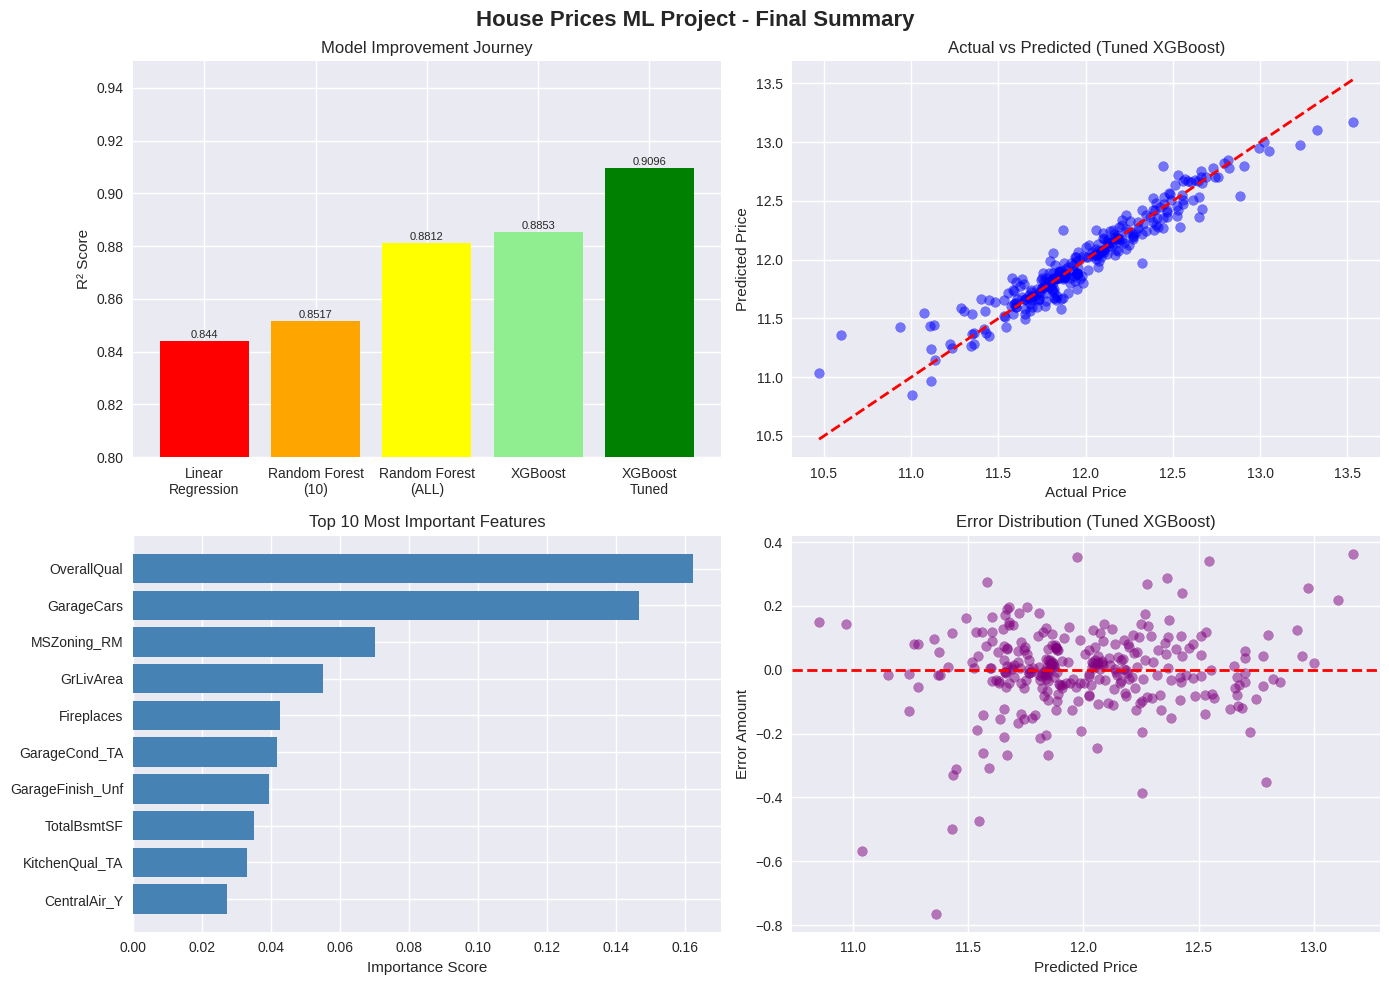

Final visualization saved to outputs/final_summary.png ✅


In [34]:
# Final Summary Visualization!
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('House Prices ML Project - Final Summary', 
             fontsize=16, fontweight='bold')

# Chart 1 - Model Comparison
models = ['Linear\nRegression', 'Random Forest\n(10)', 
          'Random Forest\n(ALL)', 'XGBoost', 'XGBoost\nTuned']
r2_scores = [0.8440, 0.8517, 0.8812, 0.8853, 0.9096]
colors = ['red', 'orange', 'yellow', 'lightgreen', 'green']

axes[0,0].bar(models, r2_scores, color=colors)
axes[0,0].set_title('Model Improvement Journey')
axes[0,0].set_ylabel('R² Score')
axes[0,0].set_ylim(0.80, 0.95)
for i, v in enumerate(r2_scores):
    axes[0,0].text(i, v + 0.001, str(v), ha='center', fontsize=8)

# Chart 2 - Actual vs Predicted
axes[0,1].scatter(y_test_all, xgb_best_pred, alpha=0.5, color='blue')
axes[0,1].plot([y_test_all.min(), y_test_all.max()],
               [y_test_all.min(), y_test_all.max()],
               'r--', linewidth=2)
axes[0,1].set_title('Actual vs Predicted (Tuned XGBoost)')
axes[0,1].set_xlabel('Actual Price')
axes[0,1].set_ylabel('Predicted Price')

# Chart 3 - Feature Importance
xgb_importance = pd.DataFrame({
    'Feature': X_train_all.columns,
    'Importance': xgb_best.feature_importances_
}).sort_values('Importance', ascending=False).head(10)

axes[1,0].barh(xgb_importance['Feature'], 
               xgb_importance['Importance'], 
               color='steelblue')
axes[1,0].set_title('Top 10 Most Important Features')
axes[1,0].set_xlabel('Importance Score')
axes[1,0].invert_yaxis()

# Chart 4 - Residuals
residuals = y_test_all - xgb_best_pred
axes[1,1].scatter(xgb_best_pred, residuals, alpha=0.5, color='purple')
axes[1,1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1,1].set_title('Error Distribution (Tuned XGBoost)')
axes[1,1].set_xlabel('Predicted Price')
axes[1,1].set_ylabel('Error Amount')

plt.tight_layout()
plt.savefig('outputs/final_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print("Final visualization saved to outputs/final_summary.png ✅")